# Synthetic Image Compression

In this notebook, we will explore various techniques for compressing synthetic images, taking advantage of a particular structure in the data. Our goal is to reduce a large number of pixels to a smaller set of parameters and preparing a graph representation of the image. The primary constraint on this compression is that the reconstruction should be lossless, meaning that we should be able to perfectly reconstruct the original image from the compressed representation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gbox as gb

## Create a target Image

Image size: (256, 512)


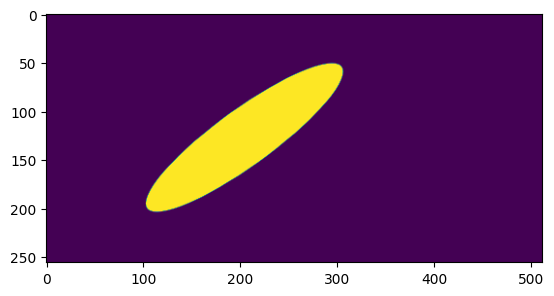

In [2]:
img_h, img_w = 256, 512

ellipse = gb.Ellipse(4.1, 1.0, (1.0, 0.0), np.pi * 0.25)
ell_arr = ellipse.plot(
    shape_options={"facecolor": "white", "edgecolor": "None"},
    bg_options={"facecolor": "black", "edgecolor": "None"},
    image_options={"mode": "L", "size": (img_w, img_h)},
    bounds=[-5.0, -5.0, 10.0, 5.0],
    as_array=True,
)
img_size = ell_arr.shape
print(f"Image size: {img_size}")
plt.imshow(ell_arr)
plt.show()

## QuadTree Implementation

Number of original image size: 131072

Number of nodes: 1953
Reduction in number of nodes: 98.510 %
Is reconstructed img same?:  True


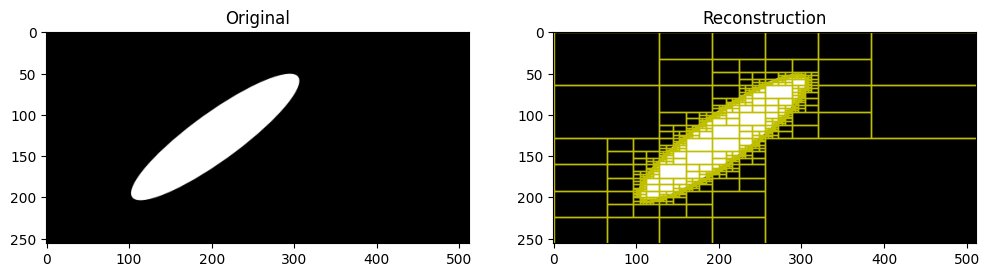

Summary after horizontal and vertical merging...

Number of nodes: 1308
Reduction in number of nodes: 99.002 %
Is reconstructed img same?:  True


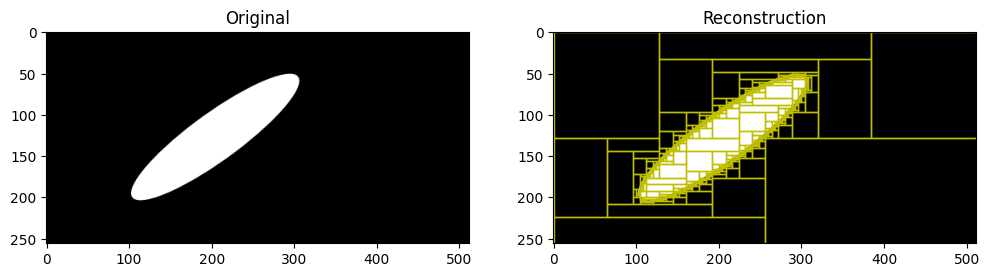

In [3]:
class QuadNode:
    def __init__(self, value=None, children=None):
        self.value = value
        self.children = children

    @property
    def is_leaf(self):
        return self.children is None


class QuadTreeBuilder:
    def __init__(self):
        self._num_nodes = 0
        self.leaves = []  # [x, y, dx, dy, val]

    @property
    def num_nodes(self):
        n_leaves = len(self.leaves)
        return n_leaves if n_leaves != 0 else self._num_nodes

    def build(self, img):
        if img.min() == img.max():
            self._num_nodes += 1
            return QuadNode(value=img[0, 0])

        h, w = img.shape

        # Stop if block is a single pixel

        # Cases when four children are not possible
        if h == 1 or w == 1:
            if h == 1 and w == 1:
                self._num_nodes += 1
                return QuadNode(value=img[0, 0])
            elif h == 1 and w != 1:
                w2 = w // 2
                children = [self.build(img[:, :w2]), self.build(img[:, w2:])]
                return QuadNode(children=children)
            elif w == 1 and h != 1:
                h2 = h // 2
                children = [self.build(img[:h2, :]), self.build(img[h2:, :])]
                return QuadNode(children=children)
        else:
            # QuadTree with four children
            h2 = h // 2
            w2 = w // 2
            children = [
                self.build(img[:h2, :w2]),
                self.build(img[:h2, w2:]),
                self.build(img[h2:, :w2]),
                self.build(img[h2:, w2:]),
            ]

        return QuadNode(children=children)

    def collect_leaves(self, node: QuadNode, x, y, h, w):
        if node.is_leaf:
            self.leaves.append((x, y, h, w, node.value))
            return

        if len(node.children) == 4:
            h2, w2 = h // 2, w // 2
            self.collect_leaves(node.children[0], x, y, h2, w2)
            self.collect_leaves(node.children[1], x, y + w2, h2, w - w2)
            self.collect_leaves(node.children[2], x + h2, y, h - h2, w2)
            self.collect_leaves(
                node.children[3], x + h2, y + w2, h - h2, w - w2
            )
        elif len(node.children) == 2:
            if h == 1:  # splitting horizontal patch
                w2 = w // 2
                self.collect_leaves(node.children[0], x, y, h, w2)
                self.collect_leaves(node.children[1], x, y + w2, h, w - w2)
            else:  # splitting vertical patch
                h2 = h // 2
                self.collect_leaves(node.children[0], x, y, h2, w)
                self.collect_leaves(node.children[1], x + h2, y, h - h2, w)

    def reconstruct(self, root_node, root_origin, h, w, target_size):
        if len(self.leaves) == 0:
            self.collect_leaves(root_node, *root_origin, h, w)
        reconstructed = np.zeros(target_size)
        for x, y, h, w, value in self.leaves:
            reconstructed[x : x + h, y : y + w] = value
        return reconstructed

    def visualise(self, root_node, root_origin, h, w, original_arr):
        if len(self.leaves) == 0:
            self.collect_leaves(root_node, *root_origin, h, w)

        fig, axs = plt.subplots(1, 2, figsize=(12, 6))
        axs[0].imshow(original_arr, cmap="gray")
        axs[0].set_title("Original")

        axs[1].imshow(original_arr, cmap="gray")
        axs[1].set_title("Reconstruction")
        for x, y, h, w, _ in self.leaves:
            rect = plt.Rectangle(
                (y, x),
                w,
                h,
                edgecolor="y",
                facecolor="none",
                linewidth=1.0,
            )
            axs[1].add_patch(rect)

        plt.show()
        plt.close(fig)

    def merge_horizontal_and_vertical_blocks(self):
        # horizontal merging
        blocks = sorted(self.leaves, key=lambda b: (b[0], b[1]))
        merged = []

        prev = None

        for x, y, h, w, val in blocks:
            if prev is None:
                prev = [x, y, h, w, val]
                continue

            px, py, ph, pw, pv = prev

            if x == px and y == py + pw and ph == h and pv == val:
                prev[3] += w  # extend width
            else:
                merged.append(tuple(prev))
                prev = [x, y, h, w, val]

        if prev:
            merged.append(tuple(prev))

        # Vertical merging

        blocks = sorted(merged, key=lambda r: (r[1], r[0]))
        merged = []

        prev = None

        for x, y, h, w, val in blocks:
            if prev is None:
                prev = [x, y, h, w, val]
                continue

            px, py, ph, pw, pv = prev

            if y == py and x == px + ph and pw == w and pv == val:
                prev[2] += h
            else:
                merged.append(tuple(prev))
                prev = [x, y, h, w, val]

        if prev:
            merged.append(tuple(prev))

        self.leaves = merged


qtb = QuadTreeBuilder()
qroot_node = qtb.build(ell_arr)
num_original_nodes = ell_arr.size
print(f"Number of original image size: {num_original_nodes}")

pct_reduction = (1.0 - (qtb.num_nodes / num_original_nodes)) * 100
recon = qtb.reconstruct(qroot_node, (0, 0), *ell_arr.shape, ell_arr.shape)
is_same = np.all(recon == ell_arr)
print(f"\nNumber of nodes: {qtb.num_nodes}")
print(f"Reduction in number of nodes: {pct_reduction:.3f} %")
print("Is reconstructed img same?: ", is_same)
qtb.visualise(qroot_node, (0, 0), *ell_arr.shape, ell_arr)

print("Summary after horizontal and vertical merging...")
qtb.merge_horizontal_and_vertical_blocks()

pct_reduction = (1.0 - (qtb.num_nodes / num_original_nodes)) * 100
recon = qtb.reconstruct(qroot_node, (0, 0), *ell_arr.shape, ell_arr.shape)
is_same = np.all(recon == ell_arr)
print(f"\nNumber of nodes: {qtb.num_nodes}")
print(f"Reduction in number of nodes: {pct_reduction:.3f} %")
print("Is reconstructed img same?: ", is_same)
qtb.visualise(qroot_node, (0, 0), *ell_arr.shape, ell_arr)


## A short study on how ellipse orientation affects the compression

In [4]:
def get_nodes_(
    aspect_ratio, area_fraction, num_angles=10, image_size=(256, 256)
):
    angles = np.linspace(0.0, np.pi * 0.5, num_angles)
    bounds = [-5.0, -5.0, 5.0, 5.0]
    ell_centre = (0.0, 0.0)
    area = (bounds[2] - bounds[0]) * (bounds[3] - bounds[1])

    results = []
    b = np.sqrt((area_fraction * area) / (np.pi * aspect_ratio))
    a = aspect_ratio * b
    for a_ang in angles:
        ellipse = gb.Ellipse(a, b, ell_centre, a_ang)
        ell_arr = ellipse.plot(
            shape_options={"facecolor": "white", "edgecolor": "None"},
            bg_options={"facecolor": "black", "edgecolor": "None"},
            image_options={"mode": "L", "size": image_size},
            bounds=bounds,
            as_array=True,
        )

        qtb = QuadTreeBuilder()
        qroot_node = qtb.build(ell_arr)
        assert np.all(
            qtb.reconstruct(qroot_node, (0, 0), *image_size, image_size)
            == ell_arr
        )
        a_result = [np.rad2deg(a_ang), qtb.num_nodes]

        qtb.merge_horizontal_and_vertical_blocks()
        assert np.all(
            qtb.reconstruct(qroot_node, (0, 0), *image_size, image_size)
            == ell_arr
        )
        a_result.append(qtb.num_nodes)
        results.append(a_result)

    results = np.array(results, dtype=np.float64)
    return results

In [5]:
aspect_ratios = (1.0, 2.0, 5.0)
area_fractions = (0.2, 0.5, 0.8)
image_size = (256, 256)
collection = {}
for i, aar in enumerate(aspect_ratios):
    for j, aaf in enumerate(area_fractions):
        collection[(aar, aaf)] = get_nodes_(aar, aaf, 100, image_size)

### Variation of reduced nodes fraction at various aspect ratios, area fractions and ellipse orientations

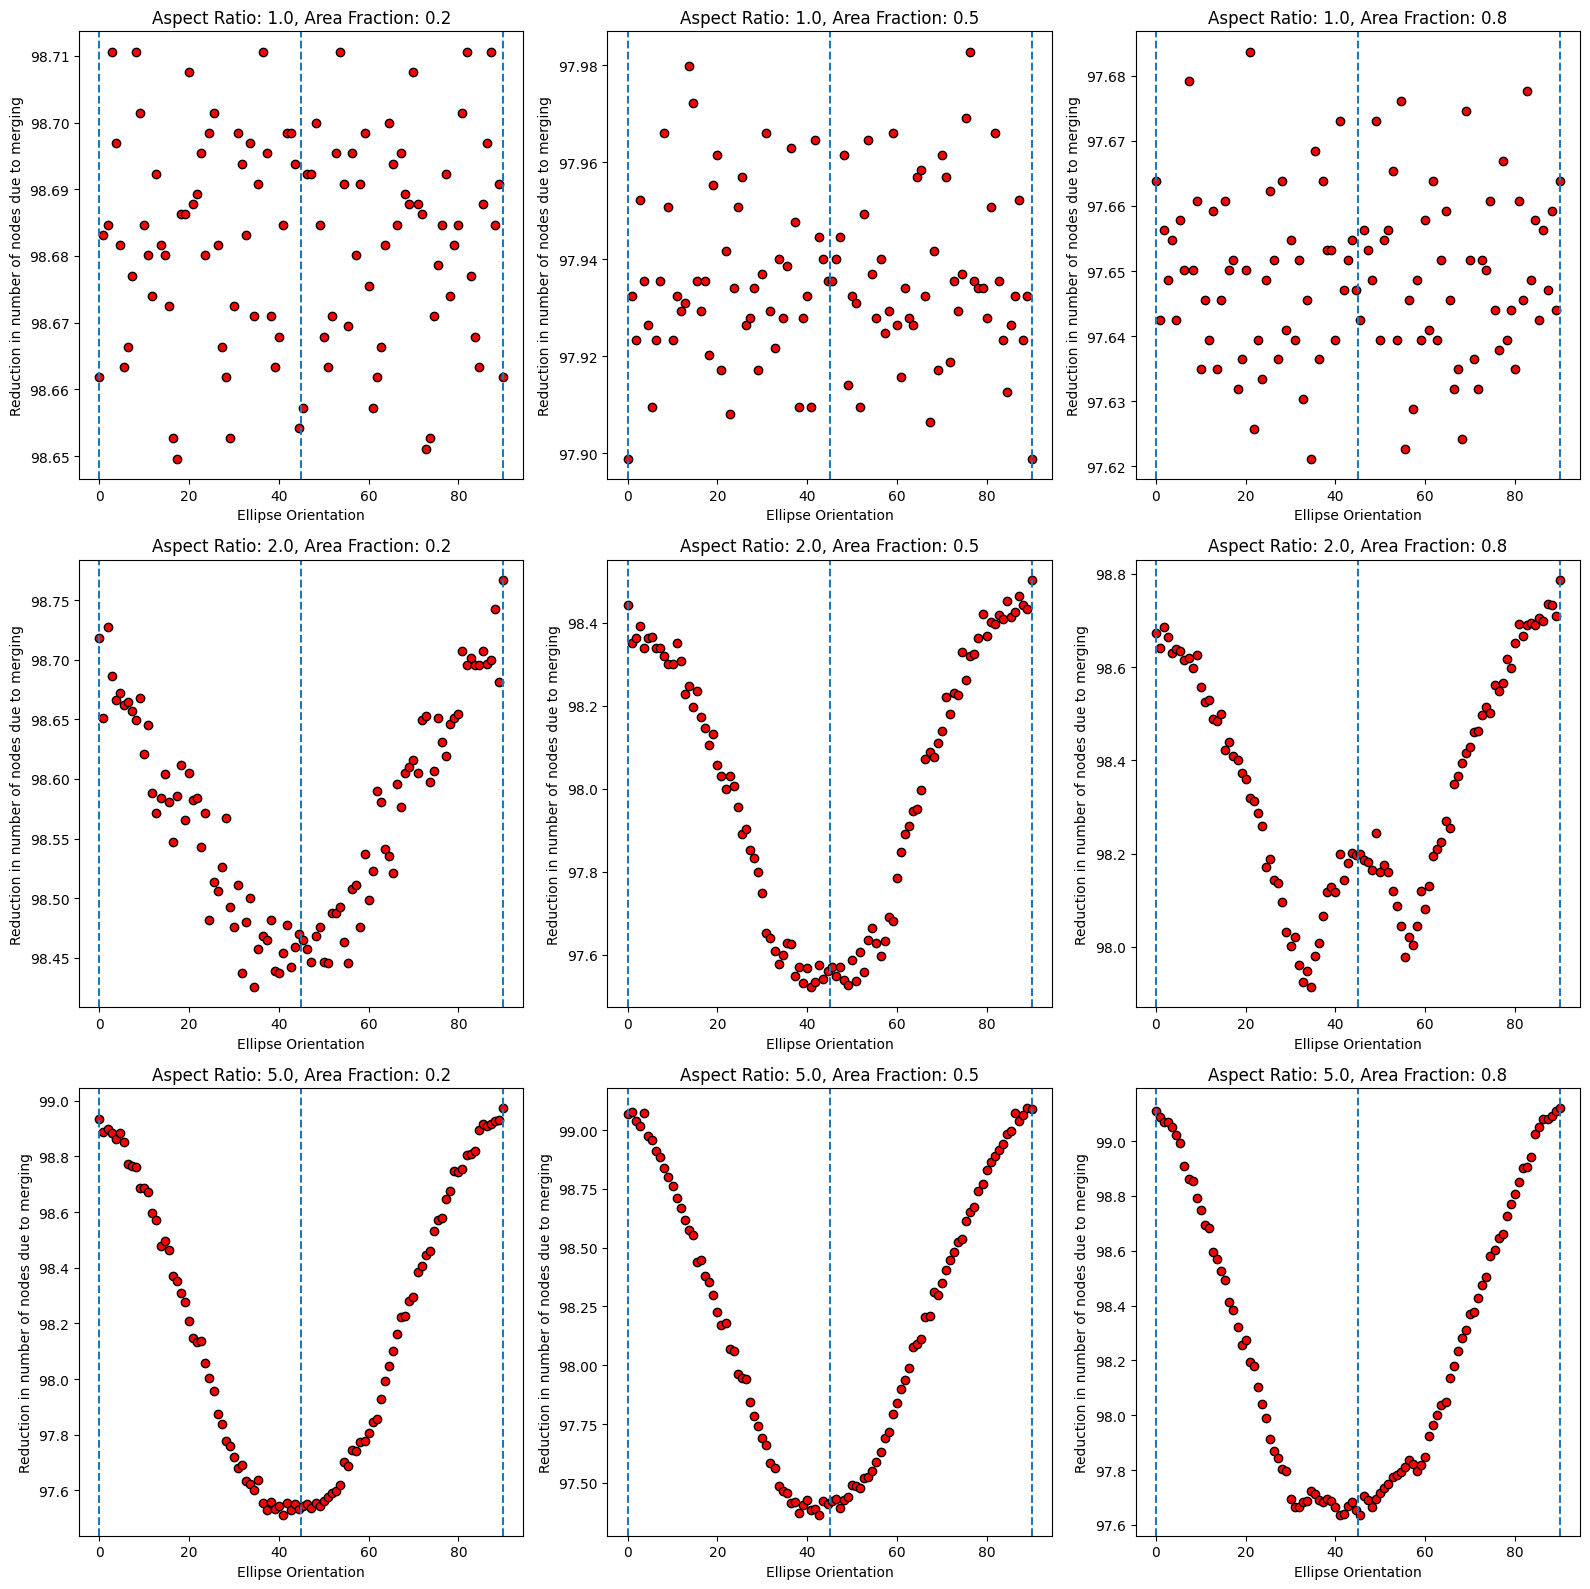

In [6]:
num_original_nodes = image_size[0] * image_size[1]

fig, axs = plt.subplots(3, 3, figsize=(16, 16))
for i, aar in enumerate(aspect_ratios):
    for j, aaf in enumerate(area_fractions):
        node_info = collection[(aar, aaf)]
        x = node_info[:, 0]
        y = (1.0 - node_info[:, 2] / num_original_nodes) * 100
        axs[i, j].scatter(x, y, c='r', edgecolors='k')
        axs[i, j].axvline(x=0.0, linestyle="dashed")
        axs[i, j].axvline(x=45.0, linestyle="dashed")
        axs[i, j].axvline(x=90.0, linestyle="dashed")
        axs[i, j].set_title(f"Aspect Ratio: {aar}, Area Fraction: {aaf}")
        axs[i, j].set_xlabel("Ellipse Orientation")
        axs[i, j].set_ylabel("Reduction in number of nodes due to merging")
plt.tight_layout()
plt.show()

In the above plot, we can see that reduction in nodes is higher at ellipse orientations closer to 0 and 90 degrees, and lower at orientations closer to 45 degrees.

## Adaptive Rectangular Partitioning

For further compression, we can use an adaptive rectangular partitioning
method instead of a quad tree. This method allows for more flexible
partitioning of the image, which can lead to better compression ratios,
especially for images with non-square features. This apprach results in a
anisiotropic patches, while the quad tree results in a more isotropic
kind of partitioning. In some cases, the anisotropic patches is desirable,
as it can better capture the structure of the image, while in some other
cases, the isotropic patches can be more effective. The choice between the
two methods depends on the specific characteristics of the image
being compressed and the final use case for the compressed representation.

Image shape: (256, 512)
Max row: 256
Max col: 512
Ell ARr shape: (256, 512)
Number of rectangles                              :1061
Reduction in number of nodes                      :99.191 %
Fraction of base nodes                            :0.809 %
img_size: (256, 512)
(256, 512)
Reconstruction correct                            :True


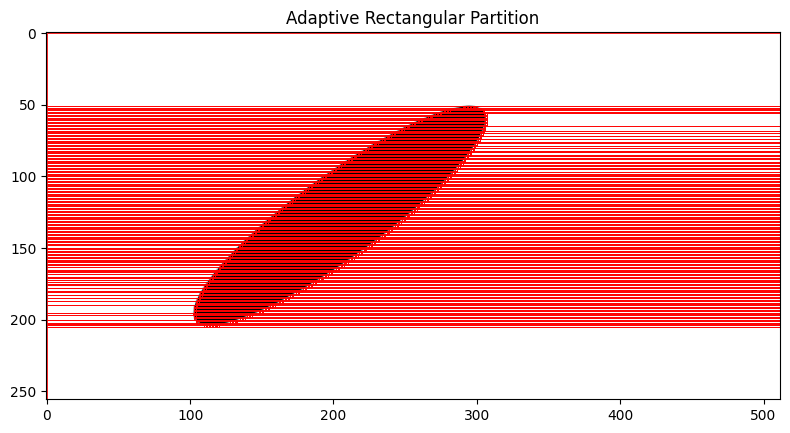

In [16]:
class AdaptiveRectangularPartition:

    def __init__(self):
        self.rectangles = []

    @property
    def num_nodes(self):
        return len(self.rectangles)

    def partition(self, img):

        h, w = img.shape

        active = {}
        rectangles = []

        for r in range(h):

            row = img[r]
            start = 0
            runs = []

            # detect horizontal runs
            for c in range(1, w):
                if row[c] != row[c - 1]:
                    runs.append((start, c - start, row[c - 1]))
                    start = c

            runs.append((start, w - start, row[-1]))

            new_active = {}

            for start, dx, val in runs:

                key = (start, dx, val)

                if key in active:
                    x, y, dx0, dy0, v0 = active[key]
                    new_active[key] = (x, y, dx0, dy0 + 1, v0)

                else:
                    new_active[key] = (r, start, dx, 1, val)

            # rectangles that stopped growing
            for key in active:
                if key not in new_active:
                    rectangles.append(active[key])

            active = new_active

        rectangles.extend(active.values())

        self.rectangles = rectangles

        print("Image shape:", img.shape)
        print("Max row:", max([x + dy for x, _, _, dy, _ in self.rectangles]))
        print("Max col:", max([y + dx for _, y, dx, _, _ in self.rectangles]))


    def reconstruct(self, shape):

        img = np.zeros(shape)

        for x, y, dx, dy, val in self.rectangles:
            img[x : x + dy, y : y + dx] = val

        return img

    def visualise(self, original_arr):

        fig, axs = plt.subplots(figsize=(8, 8))

        axs.imshow(original_arr, cmap="gray_r")
        axs.set_title("Adaptive Rectangular Partition")

        for x, y, dx, dy, _ in self.rectangles:
            rect = plt.Rectangle(
                (y, x),   # matplotlib uses (col,row)
                dx,
                dy,
                edgecolor="r",
                facecolor="none",
                linewidth=0.6,
            )
            axs.add_patch(rect)
        
        plt.tight_layout()
        plt.show()

arp = AdaptiveRectangularPartition()
arp.partition(ell_arr)

print(f"Ell ARr shape: {ell_arr.shape}")
print(f"{'Number of rectangles':50s}:{arp.num_nodes}")

pct_reduction = (1.0 - (arp.num_nodes / ell_arr.size)) * 100
print(f"{'Reduction in number of nodes':50s}:{pct_reduction:.3f} %")
print(f"{'Fraction of base nodes':50s}:{(100.0 - pct_reduction):.3f} %")

print(f"img_size: {ell_arr.shape}")
recon = arp.reconstruct(ell_arr.shape)
print(recon.shape)

print(f"{'Reconstruction correct':50s}:{np.all(recon == ell_arr)}")

arp.visualise(ell_arr)